In [2]:
# 라이브러리 호출
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

## 원본 데이터 호출 및 데이터프레임 제작

In [3]:
# 데이터 프레임을 출력할 때, 행과 컬럼이 모두 생략되지 않도록 하는 코드
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 원본 파일을 열어보니 컬럼명이 다중행이라서 두 행을 모두 불러옴
df_original = pd.read_csv("../data/DieCasting_Quality_Raw_Data.csv", header=[0,1])

df_original.head(5)

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                        \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0               214           0.008                 10             258   
1               217           0.008                 11             257   
2               214           0.008                 11             257   
3               217           0.008                 11             257   
4               217           0.008                 12             257   

                                                                           \
  Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7               0.044             1037        7.8          0.7   
1       20.7               0.044             1052        7.8          0.7   
2       20.8               0.041             1037        7.8          0.7   
3       20.7               0.043             1051        7.8          0.7   
4       20.7               0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0        

In [4]:
df_original.shape

(7535, 57)

In [5]:
# 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df_original.columns if col[0] == 'Process']
sensor_cols = [col for col in df_original.columns if col[0] == 'Sensor']
defects_cols = [col for col in df_original.columns if col[0] == 'Defects']

# 데이터 프레임 생성
df_process = df_original[process_cols].copy()
df_sensor = df_original[sensor_cols].copy()
df_defects = df_original[defects_cols].copy()

# 두 번째 행에 있는 컬럼명만 사용하도록 변경
# get_level_values(가져오고 싶은 레벨 인덱스) - level 0: 첫번째 행, level 1: 두번째 행
# 왼쪽 .columns: 컬럼명을 바꾸기 위한 설정
# 오른쪽 .columns: 기존 다중레벨 컬럼 가져오기 → get_level_values(1)로 Level 1만 추출
df_process.columns = df_process.columns.get_level_values(1)
df_sensor.columns = df_sensor.columns.get_level_values(1)
df_defects.columns = df_defects.columns.get_level_values(1)

# csv 파일로 저장
df_process.to_csv('process.csv', index=False)
df_sensor.to_csv('sensor.csv', index=False)
df_defects.to_csv('defects.csv', index=False)

print("✅ 파일 분리 완료!")
print(f"Process: 컬럼 {len(process_cols)}개")
print(f"Sensor: 컬럼 {len(sensor_cols)}개")
print(f"Defects: 컬럼 {len(defects_cols)}개")

✅ 파일 분리 완료!
Process: 컬럼 17개
Sensor: 컬럼 14개
Defects: 컬럼 26개


---
## 결측치 개수 및 비율 확인

In [6]:
def show_df_info(df, df_name):
    
    print(f"{'='*60}")
    print(f"⬇️{df_name} 데이터프레임 정보⬇️")
    print(f"{'='*60}")
    
    # .values: Numpy 배열로 반환
    # 각각의 값이 인덱스가 안맞아서 DataFrame을 만들 때 충돌되지 않도록 하기 위해서 사용
    info_df = pd.DataFrame({
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null_Cnt': df.count().values,
        'Null_Cnt': df.isnull().sum().values,
        'Null_pct(%)': (df.isnull().sum() / len(df) * 100).round(2).values
    })
    
    display(info_df)
    return info_df

In [7]:
process_info = show_df_info(df_process, 'Process')
sensor_info = show_df_info(df_sensor, 'Sensor')
defects_info = show_df_info(df_defects, 'Defects')

⬇️Process 데이터프레임 정보⬇️


,Column Name,Data Type,Non-Null_Cnt,Null_Cnt,Null_pct(%)
0,id,int64,7535,0,0.0
1,Product_Type,int64,7535,0,0.0
2,Shot,int64,7535,0,0.0
3,Velocity_1,float64,7535,0,0.0
4,Velocity_2,float64,7535,0,0.0
5,Velocity_3,float64,7535,0,0.0
6,High_Velocity,float64,7535,0,0.0
7,Cylinder_Pressure,int64,7535,0,0.0
8,Rapid_Rise_Time,float64,7535,0,0.0
9,Biscuit_Thickness,int64,7535,0,0.0


⬇️Sensor 데이터프레임 정보⬇️


,Column Name,Data Type,Non-Null_Cnt,Null_Cnt,Null_pct(%)
0,Melting_Furnace_Temp,float64,7535,0,0.00
1,Air_Pressure,float64,7535,0,0.00
2,Air_Pressure_Min,int64,7535,0,0.00
3,Air_Pressure_Max,int64,7535,0,0.00
4,Coolant_Temp,float64,7535,0,0.00
5,Coolant_Temp_Min,int64,7535,0,0.00
6,Coolant_Temp_Max,int64,7535,0,0.00
7,Coolant_Pressure,float64,7535,0,0.00
8,Factory_Temp,float64,7445,90,1.19
9,Factory_Temp_Min,float64,7445,90,1.19


⬇️Defects 데이터프레임 정보⬇️


,Column Name,Data Type,Non-Null_Cnt,Null_Cnt,Null_pct(%)
0,Short_Shot_1,int64,7535,0,0.0
1,Bubble_1,int64,7535,0,0.0
2,Exfoliation_1,int64,7535,0,0.0
3,Blow_Hole_1,int64,7535,0,0.0
4,Stain_1,int64,7535,0,0.0
5,Dent_1,int64,7535,0,0.0
6,Deformation_1,int64,7535,0,0.0
7,Contamination_1,int64,7535,0,0.0
8,Impurity_1,int64,7535,0,0.0
9,Crack_1,int64,7535,0,0.0


---
## Product, Sensor관련 데이터의 분포 시각화

In [8]:
# Product, Sensor관련 데이터의 분포 시각화(히스토그램)

def plot_histograms(df, df_name, exclude_cols=['id', 'Shot', 'Product_Type'], bins=30, figsize=(20, 15)):
    
    # id, shot 컬럼 제외
    plot_cols = [col for col in df.columns if col not in exclude_cols]
    
    n_cols = len(plot_cols)
    n_rows = int(np.ceil(n_cols / 5))
    
    fig, axes = plt.subplots(n_rows, 5, figsize=figsize)
    axes = axes.flatten() # 행+열로 구성된 인덱스를 순서 인덱스로 변경
    
    for idx, col in enumerate(plot_cols):
        ax = axes[idx]
        
        # 왼쪽 y축: 히스토그램 (빈도수)
        sns.histplot(df[col], bins=bins, ax=ax, kde=False,
                    stat='count',  # 빈도수
                    color='steelblue', 
                    edgecolor='black', 
                    alpha=0.7)
        
        ax.set_ylabel('Frequency', fontsize=8)
        
        # 오른쪽 y축: KDE (밀도)
        ax2 = ax.twinx()  # 두 번째 y축 생성
        sns.kdeplot(df[col], ax=ax2, color='red', linewidth=2)
        
        ax2.set_ylabel('Density', fontsize=8)
        
        # 제목 및 x축
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # 남은 subplot 제거
    for idx in range(n_cols, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle(f'{df_name}와 관련된 데이터들의 Histograms과 KDE 곡선', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

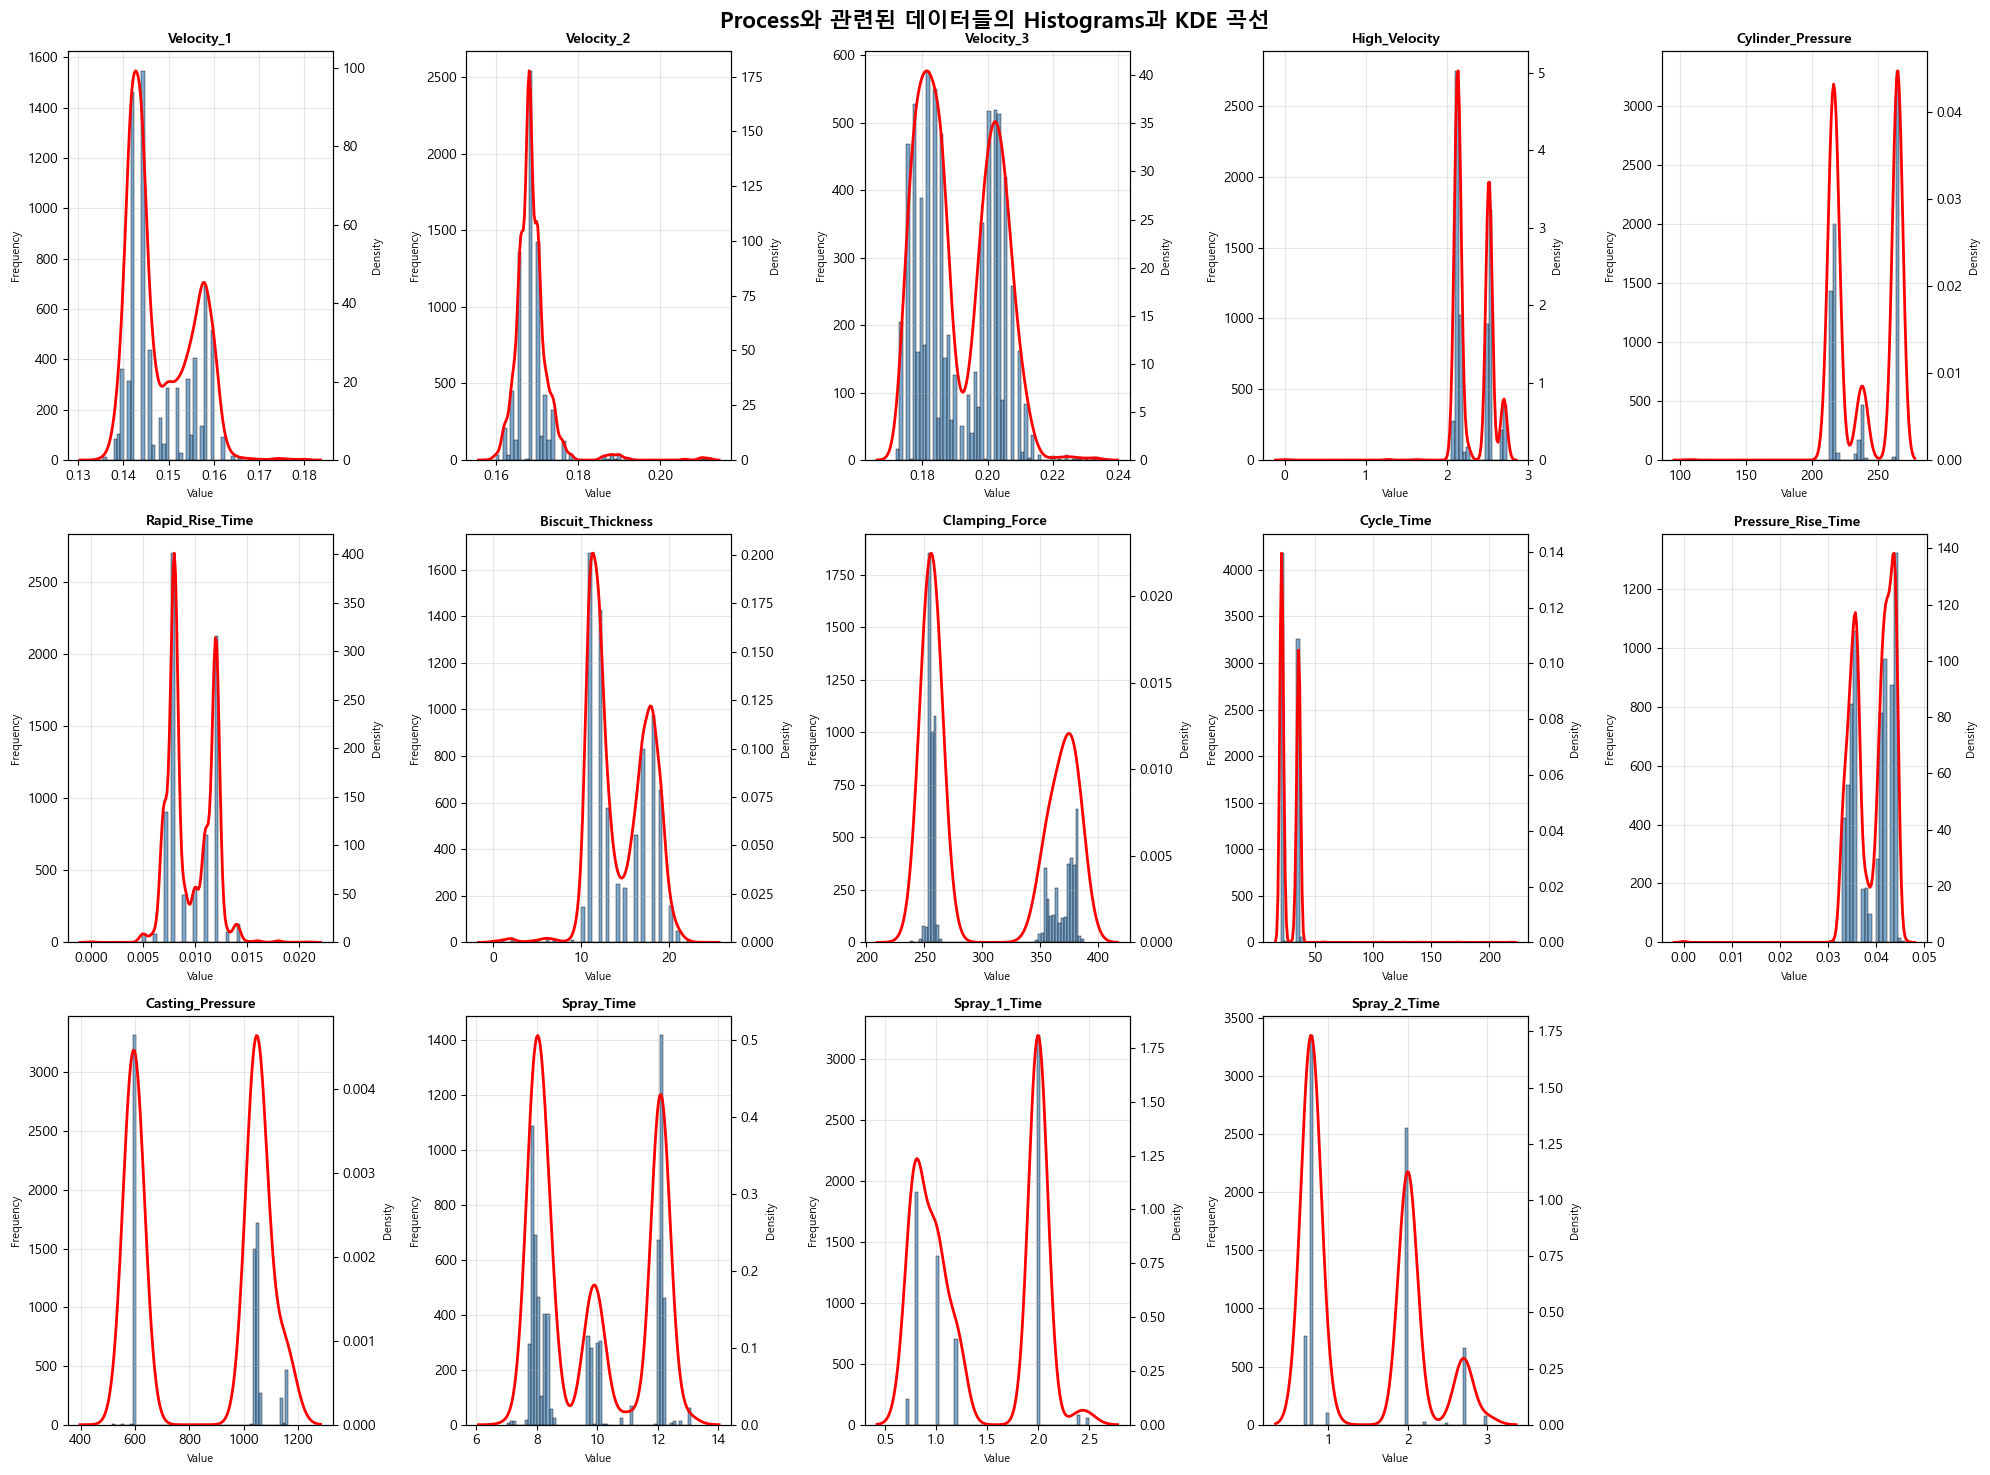

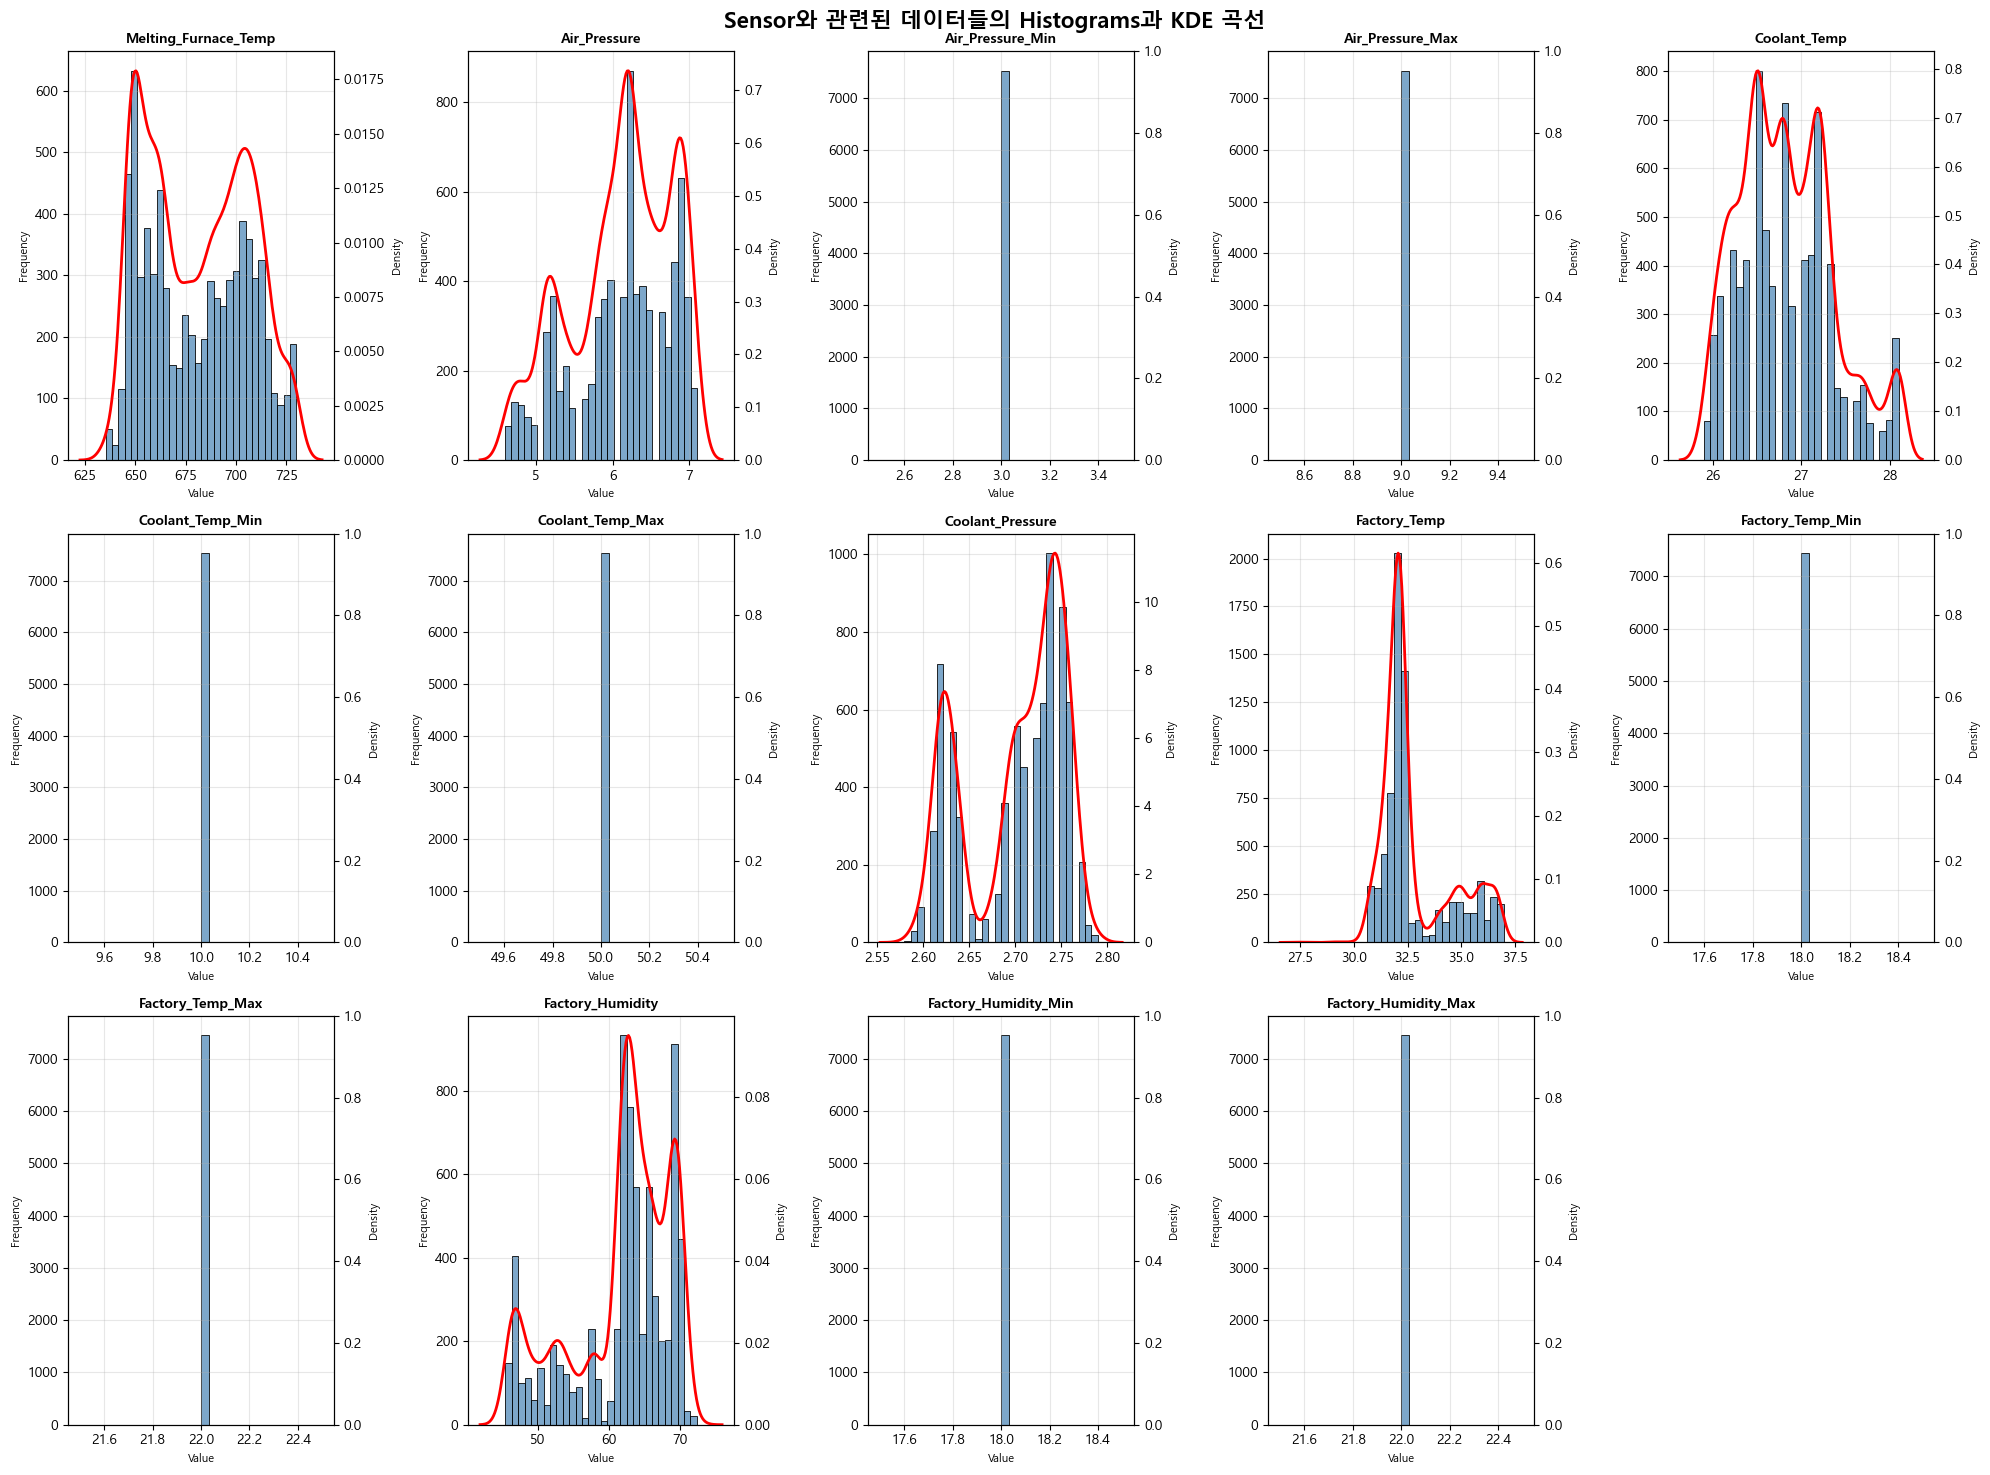

In [9]:
# 함수 실행
plot_histograms(df_process, 'Process', bins=60)
plot_histograms(df_sensor, 'Sensor')

---
## 기초통계량 확인
- Process, Sensor 관련 데이터 확인
- Defect 관련 데이터의 고유값 확인

In [10]:
# Process, Sensor 관련 데이터 확인
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"⬇️{df_name} 관련 데이터의 기초통계량⬇️")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기본 통계량
    stats_df = df_copied.describe().T
    
    # 고유값의 개수, 왜도, 첨도 추가
    stats_df['Unique'] = df_copied.nunique()
    stats_df['Skewness'] = df_copied.skew()
    stats_df['Kurtosis'] = df_copied.kurtosis()
    
    # 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Unique': '고유값',
        'Skewness': '왜도',
        'Kurtosis': '첨도'
    }, inplace=True)
    
    display(stats_df)
    
    return stats_df

In [11]:
# 함수 실행
stats_df_process = create_statistics_summary(df_process, 'Process')
stats_df_sensor = create_statistics_summary(df_sensor, 'Sensor')


⬇️Process 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
id,7535.0,3.767454e+06,2.175264e+06,1.000,1883893.000,3767193.000,5650924.500,7534661.000,7535,-0.000049,-1.199848
Product_Type,7535.0,1.441672e+00,4.966192e-01,1.000,1.000,1.000,2.000,2.000,2,0.234962,-1.945309
Shot,7535.0,4.537989e+02,3.194517e+02,0.000,195.000,401.000,645.000,1296.000,1271,0.700880,-0.281888
Velocity_1,7535.0,1.482190e-01,7.134201e-03,0.134,0.142,0.144,0.156,0.180,33,0.638906,-0.689695
Velocity_2,7535.0,1.688005e-01,4.720277e-03,0.158,0.166,0.168,0.170,0.212,27,4.087670,28.913573
Velocity_3,7535.0,1.911928e-01,1.156281e-02,0.172,0.181,0.188,0.202,0.234,45,0.280346,-1.105678
High_Velocity,7535.0,2.319210e+00,2.220408e-01,0.000,2.134,2.161,2.523,2.744,319,-0.347531,5.037868
Cylinder_Pressure,7535.0,2.396556e+02,2.330545e+01,107.000,217.000,239.000,265.000,266.000,22,-0.017856,-1.370291
Rapid_Rise_Time,7535.0,9.596284e-03,2.147899e-03,0.000,0.008,0.009,0.012,0.021,18,0.332233,-0.359274
Biscuit_Thickness,7535.0,1.430962e+01,3.286284e+00,0.000,11.000,13.000,17.000,24.000,24,-0.012470,-0.446597



⬇️Sensor 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
Melting_Furnace_Temp,7535.0,680.652661,25.288666,635.30,656.70,680.30,703.10,730.00,737,0.124036,-1.284874
Air_Pressure,7535.0,6.109595,0.647906,4.60,5.70,6.20,6.60,7.10,26,-0.480152,-0.673609
Air_Pressure_Min,7535.0,3.000000,0.000000,3.00,3.00,3.00,3.00,3.00,1,0.000000,0.000000
Air_Pressure_Max,7535.0,9.000000,0.000000,9.00,9.00,9.00,9.00,9.00,1,0.000000,0.000000
Coolant_Temp,7535.0,26.830126,0.525149,25.90,26.50,26.80,27.20,28.10,23,0.486100,-0.272945
Coolant_Temp_Min,7535.0,10.000000,0.000000,10.00,10.00,10.00,10.00,10.00,1,0.000000,0.000000
Coolant_Temp_Max,7535.0,50.000000,0.000000,50.00,50.00,50.00,50.00,50.00,1,0.000000,0.000000
Coolant_Pressure,7535.0,2.701155,0.052408,2.58,2.64,2.72,2.74,2.79,22,-0.571114,-1.100549
Factory_Temp,7445.0,32.829684,1.674896,27.40,31.90,32.10,33.80,37.00,67,1.107711,-0.036236
Factory_Temp_Min,7445.0,18.000000,0.000000,18.00,18.00,18.00,18.00,18.00,1,0.000000,0.000000


In [50]:
# IQR 계산
variable = 'High_Velocity'

# IQR 계산
Q1 =stats_df_process['Q1의 경계값'][variable]
Q3 =stats_df_process['Q3의 경계값'][variable]
IQR = Q3 - Q1

# 한계값 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"=== {variable} IQR 분석 ===")
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR (Q3-Q1): {IQR:.2f}")
print(f"하한 (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"상한 (Q3 + 1.5*IQR): {upper_bound:.2f}")

# 이상치 판정
outliers_iqr = (df_process[variable] < lower_bound) | (df_process[variable] > upper_bound)
n_outliers_iqr = outliers_iqr.sum()
outlier_rate_iqr = (n_outliers_iqr / len(df_process)) * 100

print(f"\n이상치 개수: {n_outliers_iqr}개 ({outlier_rate_iqr:.2f}%)")
print(f"정상 데이터: {len(df_process) - n_outliers_iqr}개 ({100-outlier_rate_iqr:.2f}%)")

=== High_Velocity IQR 분석 ===
Q1 (25%): 2.13
Q3 (75%): 2.52
IQR (Q3-Q1): 0.39
하한 (Q1 - 1.5*IQR): 1.55
상한 (Q3 + 1.5*IQR): 3.11

이상치 개수: 10개 (0.13%)
정상 데이터: 7525개 (99.87%)


---
## velocity, spray_time 관련 변수 상관관계 시각화

In [13]:
def plot_correlation_heatmap(df, columns, title):
    """특정 컬럼들의 상관관계 히트맵"""
    
    # 해당 컬럼만 선택
    df_subset = df[columns]
    
    # 상관계수 계산
    corr = df_subset.corr()
    
    # 히트맵 그리기
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, 
                annot=True,           # 숫자 표시
                fmt='.2f',            # 소수점 2자리
                cmap='coolwarm',      # 색상 (빨강-파랑)
                center=0,             # 0을 중심으로
                square=True,          # 정사각형
                linewidths=1,         # 셀 구분선
                cbar_kws={'label': 'Correlation'})
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return corr

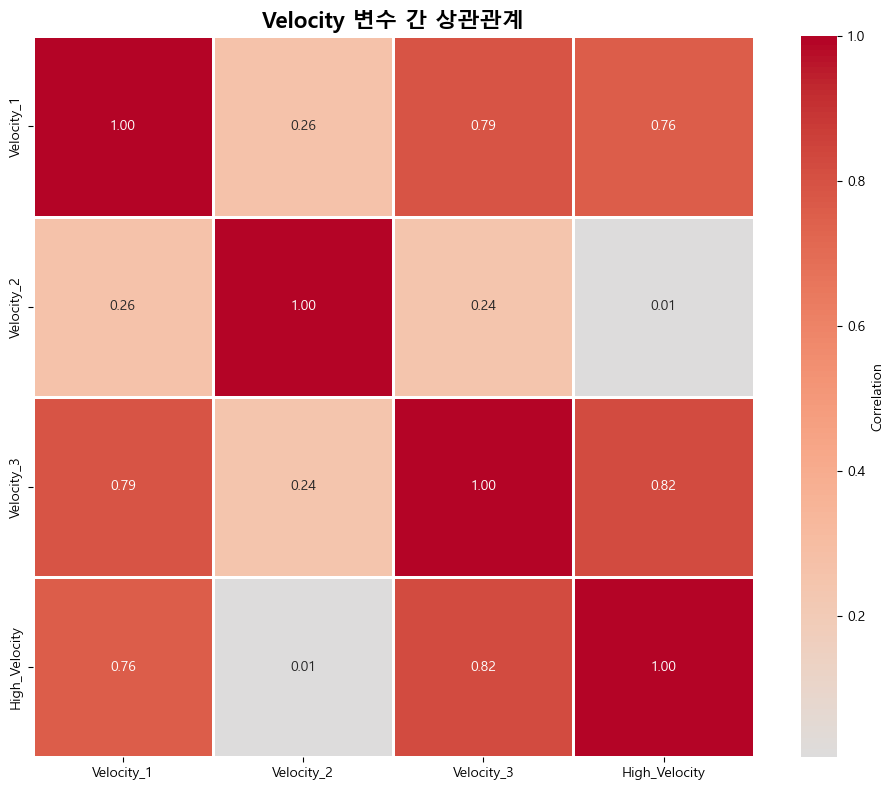

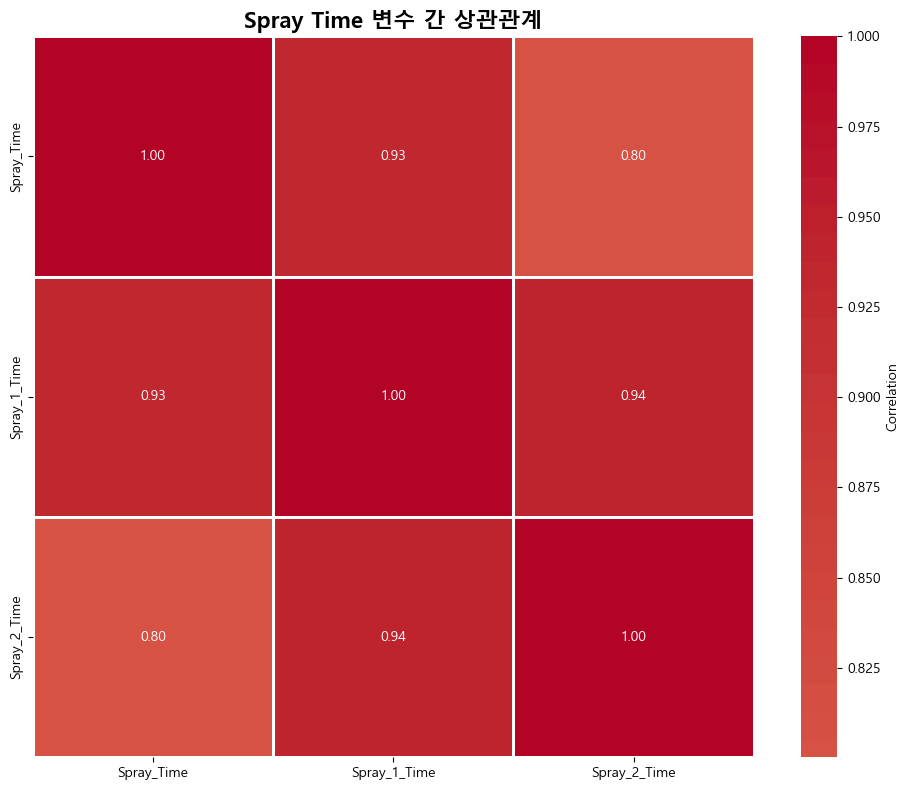

In [14]:
# Velocity 4개 변수 상관관계
velocity_cols = ["Velocity_1", "Velocity_2", "Velocity_3", "High_Velocity"]
corr_velocity = plot_correlation_heatmap(df_process, velocity_cols, 
                                         'Velocity 변수 간 상관관계')

# Spray_Time 3개 변수 상관관계
spray_cols = ["Spray_Time", "Spray_1_Time", "Spray_2_Time"]
corr_spray = plot_correlation_heatmap(df_process, spray_cols, 
                                      'Spray Time 변수 간 상관관계')

In [15]:
# 전체 데이터 고유값 확인
print("Spray_Time 고유값:")
print(df_process['Spray_Time'].unique())
print(f"고유값 개수: {df_process['Spray_Time'].nunique()}")

print("\nSpray_1_Time 고유값:")
print(df_process['Spray_1_Time'].unique()[:20])  # 처음 20개
print(f"고유값 개수: {df_process['Spray_1_Time'].nunique()}")

print("\nSpray_2_Time 고유값:")
print(df_process['Spray_2_Time'].unique()[:20])
print(f"고유값 개수: {df_process['Spray_2_Time'].nunique()}")

# 기초 통계
print("\n기초 통계:")
print(df_process[['Spray_Time', 'Spray_1_Time', 'Spray_2_Time']].describe())

Spray_Time 고유값:
[ 7.8  7.9  8.1  8.   8.3  8.4  8.2  8.5  8.6  9.8  9.7  7.7 10.8  7.3
  7.2  7.1  7.  12.5 12.4 12.2 12.7 13.  13.1 11.9 10.1 10.   9.9 10.3
 10.2 11.1 12.1 12. ]
고유값 개수: 32

Spray_1_Time 고유값:
[0.7 1.  0.8 1.2 2.  2.5 2.4]
고유값 개수: 7

Spray_2_Time 고유값:
[0.8 1.  0.7 2.2 2.  2.5 2.7 3. ]
고유값 개수: 8

기초 통계:
        Spray_Time  Spray_1_Time  Spray_2_Time
count  7535.000000   7535.000000   7535.000000
mean      9.815979      1.409104      1.396045
std       1.842438      0.557060      0.716170
min       7.000000      0.700000      0.700000
25%       8.000000      0.800000      0.800000
50%       9.700000      1.200000      0.800000
75%      12.100000      2.000000      2.000000
max      13.100000      2.500000      3.000000
